# 🎤 Spoken Digit Recognition (0–9)
### Speech Processing — Final Lab Project

---

## Group #3

| Name | Registration No. |
|------|------------------|
| Savaira Majeed | DSAI231103031 |
| Shaesta Saleem | DSAI231103043 |
| Mustajab Zahra | DSAI231103016 |
| Faizan Nazik | DSAI231103023 |
| Sarfraz Ahmad | DSAI231103048 |
| Muhammad Gulfam | DSAI231103047 |

---

## 🎯 Goal

When a person speaks a digit (0 to 9), can a computer understand which digit was spoken — just from the audio?

That is exactly what this project does!

---

## 📦 Dataset

**Name:** Free Spoken Digit Dataset (FSDD)

**Source:** https://github.com/Jakobovski/free-spoken-digit-dataset

**Why this dataset?**
- Free and open source
- Used in 50+ research papers
- Small size (~10 MB) — easy to work with
- 6 different speakers — model learns to work for anyone

| Property | Detail |
|----------|--------|
| Total Files | 3,000 WAV files |
| Speakers | 6 |
| Digits | 0 to 9 |
| Files per digit per speaker | 50 |
| Format | WAV, 8kHz, Mono |

**File name format:**
```
digit_speakerName_index.wav
Example: 3_jackson_0.wav  →  digit=3, speaker=jackson
```

---

## 🔁 Overall Flow

```
Audio File (.wav)
       ↓
Load Signal (librosa)
       ↓
EDA (Explore the data)
       ↓
   ____↓____
  |         |
  ↓         ↓
MFCC     Spectrogram
Features   Image
  |         |
  ↓         ↓
 SVM       CNN
  |         |
  ↓         ↓
   Accuracy + Confusion Matrix
       ↓
   SVM vs CNN Comparison
```

## 📥 STEP 0 — Install Libraries

📘 **Description:**

Before we start, we install all the tools we need:
- `librosa` → loads audio files and extracts features
- `tensorflow` → builds and trains the CNN deep learning model
- `scikit-learn` → builds the SVM model and evaluates results
- `matplotlib` / `seaborn` → draws graphs and plots

In [28]:
# Install all required libraries in one command
# -q means quiet mode (less output)
!pip install librosa tensorflow scikit-learn matplotlib seaborn -q

## 📂 STEP 1 — Mount Google Drive

📘 **Description:**

Our dataset is saved in Google Drive inside the folder:
`Spoken Digit Recognition (0-9) → recordings`

We connect Google Drive to Colab so we can read the files directly.

In [2]:
# Connect Google Drive to this Colab notebook
from google.colab import drive
drive.mount('/content/drive')

# Set the path to our recordings folder in Google Drive
# This is the ONLY folder we need from the dataset
DATASET_PATH = "/content/drive/MyDrive/Spoken Digit Recognition (0-9)/recordings/"

print("✅ Google Drive connected!")
print("📁 Dataset path:", DATASET_PATH)

Mounted at /content/drive
✅ Google Drive connected!
📁 Dataset path: /content/drive/MyDrive/Spoken Digit Recognition (0-9)/recordings/


## 📚 STEP 2 — Import Libraries

📘 **Description:**

We import all libraries at the top — this is standard practice so everything is ready before we start coding.

In [3]:
import os                          # to read files and folders
import numpy as np                 # for numbers and arrays
import librosa                     # for loading audio and extracting features
import librosa.display             # for visualizing audio
import matplotlib.pyplot as plt    # for drawing graphs
import seaborn as sns              # for drawing confusion matrix
import warnings
warnings.filterwarnings('ignore')  # hide unnecessary warning messages

# sklearn → for SVM model and evaluation tools
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# tensorflow → for CNN deep learning model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
# 🔍 PART 1 — Exploratory Data Analysis (EDA)

📘 **What is EDA?**

Before building any model, we first **explore and understand** our data.

EDA helps us answer:
- How many files do we have?
- Is the data balanced? (equal files per digit?)
- What does an audio signal look like?
- What do the features (MFCC, Spectrogram) look like?

These answers help us decide how to preprocess and which model to use.

### 📊 EDA — Step 1: How Many Files Are There?

📘 **Description:**
We list all the `.wav` files in our recordings folder and check the total count.

In [4]:
# Get a list of all .wav files from the recordings folder
all_files = [f for f in os.listdir(DATASET_PATH) if f.endswith('.wav')]

# Print how many files we have
print("Total files:", len(all_files))

# Show first 5 file names as examples
print("\nExample file names:")
for f in all_files[:5]:
    print(" ", f)

# Explain the file naming format
print("\n📌 Format: digit_speaker_index.wav")
print("   Example: 3_jackson_0.wav → digit=3, speaker=jackson")

Total files: 3000

Example file names:
  6_george_49.wav
  4_george_37.wav
  5_george_7.wav
  2_george_39.wav
  5_jackson_13.wav

📌 Format: digit_speaker_index.wav
   Example: 3_jackson_0.wav → digit=3, speaker=jackson


### 📊 EDA — Step 2: Class Distribution

📘 **Description:**

We count how many audio files exist for each digit (0–9).

A **balanced dataset** means every class has equal samples → no bias in training.

If one class had much more data, the model would be biased towards it.

Files per digit:
  Digit 0: 300 files
  Digit 1: 300 files
  Digit 2: 300 files
  Digit 3: 300 files
  Digit 4: 300 files
  Digit 5: 300 files
  Digit 6: 300 files
  Digit 7: 300 files
  Digit 8: 300 files
  Digit 9: 300 files


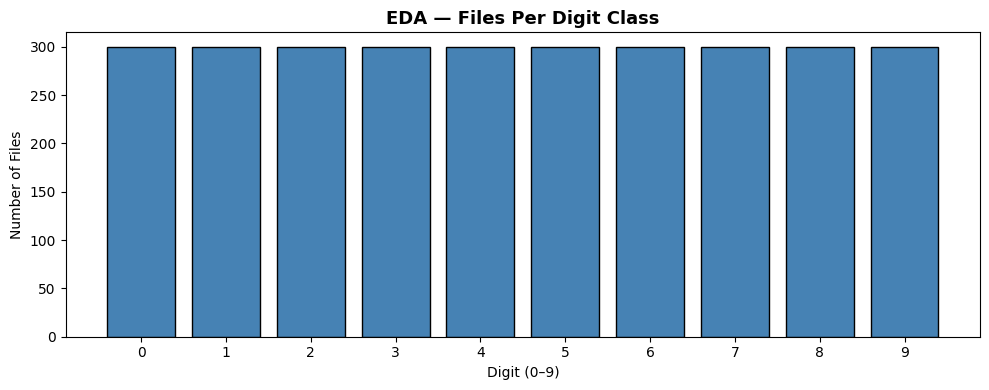

✅ Dataset is balanced — each digit has equal files!


In [5]:
# Create a dictionary to count files per digit
digit_counts = {str(i): 0 for i in range(10)}  # keys: '0' to '9'

for f in all_files:
    digit = f.split('_')[0]        # get digit from filename (first part before '_')
    if digit in digit_counts:
        digit_counts[digit] += 1   # count +1 for that digit

# Print counts
print("Files per digit:")
for digit, count in sorted(digit_counts.items()):
    print(f"  Digit {digit}: {count} files")

# Draw bar chart to visualize class balance
plt.figure(figsize=(10, 4))
plt.bar(digit_counts.keys(), digit_counts.values(), color='steelblue', edgecolor='black')
plt.title("EDA — Files Per Digit Class", fontsize=13, fontweight='bold')
plt.xlabel("Digit (0–9)")
plt.ylabel("Number of Files")
plt.xticks(range(10))
plt.tight_layout()
plt.show()

print("✅ Dataset is balanced — each digit has equal files!")

### 📊 EDA — Step 3: Speaker Distribution

📘 **Description:**

We check how many different speakers are in the dataset.

More speakers = model works better for different voices (speaker-independent recognition).

Total speakers: 6
Speaker names: ['george', 'jackson', 'lucas', 'nicolas', 'theo', 'yweweler']


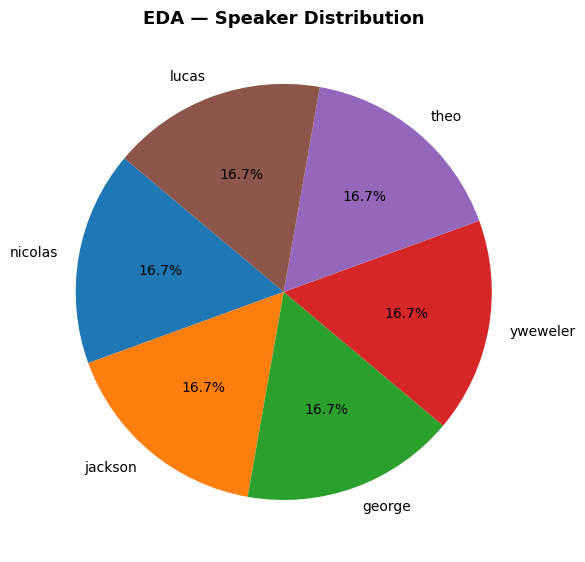

✅ All 6 speakers contribute equally to the dataset.


In [6]:
# Find all unique speaker names from filenames
speakers = set()
for f in all_files:
    speaker = f.split('_')[1]   # second part of filename is speaker name
    speakers.add(speaker)

print(f"Total speakers: {len(speakers)}")
print(f"Speaker names: {sorted(speakers)}")

# Count how many files each speaker contributed
speaker_counts = {s: 0 for s in speakers}
for f in all_files:
    speaker = f.split('_')[1]
    speaker_counts[speaker] += 1

# Draw pie chart to show speaker distribution
plt.figure(figsize=(6, 6))
plt.pie(speaker_counts.values(), labels=speaker_counts.keys(), autopct='%1.1f%%', startangle=140)
plt.title("EDA — Speaker Distribution", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ All 6 speakers contribute equally to the dataset.")

### 📊 EDA — Step 4: Audio Signal — Waveform (Time Domain)

📘 **Description:**

We load one audio file and visualize its **waveform** — how the sound amplitude changes over time.

Key terms:
- `sr` (Sample Rate) = how many samples recorded per second (8000 for this dataset)
- `Amplitude` = loudness of the sound at each moment
- High amplitude in the middle = the actual spoken digit
- Near-zero at start/end = silence (dataset is well trimmed)

Audio file     : 3_jackson_0.wav
Sample rate    : 8000 Hz
Duration       : 0.486 seconds
Total samples  : 3886


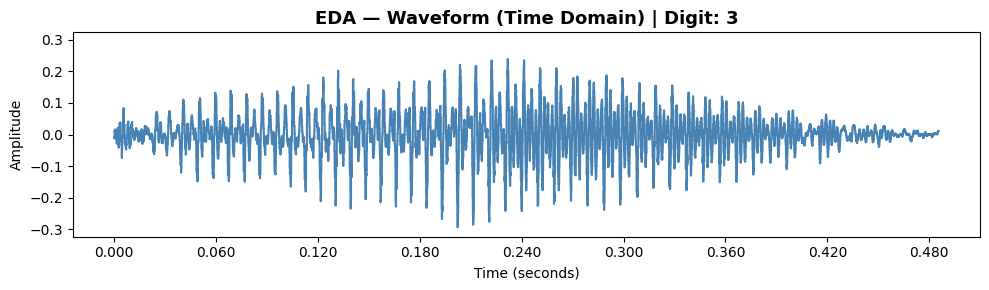

In [7]:
# Load one audio file — digit 3 by speaker jackson
sample_file = os.path.join(DATASET_PATH, "3_jackson_0.wav")

# librosa.load() reads the audio file
# signal = array of amplitude values
# sr = sample rate (samples per second)
# sr=None means keep the original sample rate (no resampling)
signal, sr = librosa.load(sample_file, sr=None)

print("Audio file     :", "3_jackson_0.wav")
print("Sample rate    :", sr, "Hz")
print("Duration       :", round(len(signal)/sr, 3), "seconds")
print("Total samples  :", len(signal))

# Plot waveform — x axis = time, y axis = amplitude
plt.figure(figsize=(10, 3))
librosa.display.waveshow(signal, sr=sr, color='steelblue')
plt.title("EDA — Waveform (Time Domain) | Digit: 3", fontsize=13, fontweight='bold')
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

### 📊 EDA — Step 5: Compare Waveforms of Different Digits

📘 **Description:**

Each digit has a different shape of waveform. This proves the signals are different — which is why a model can classify them.

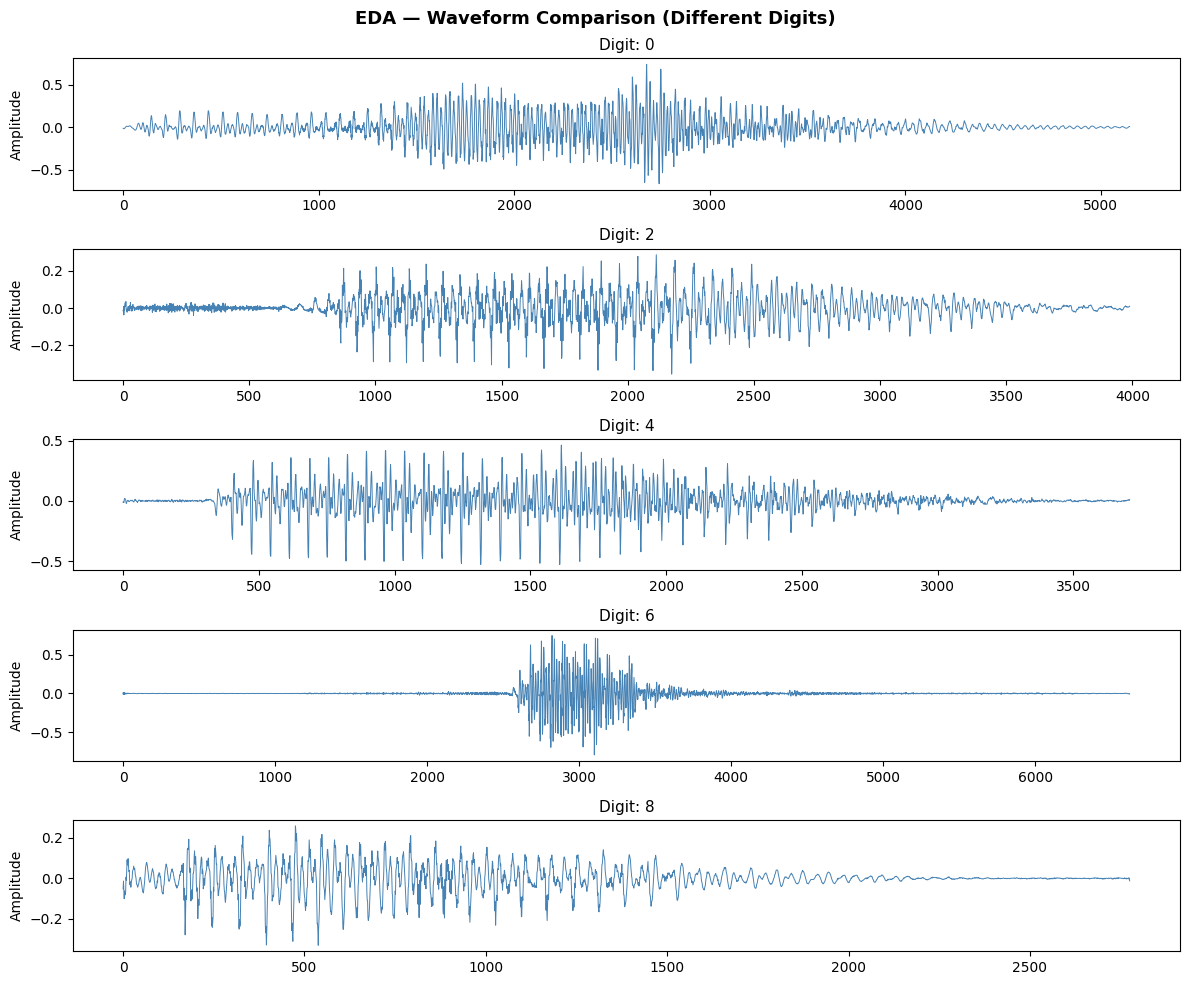

✅ Each digit has a different waveform pattern — model will learn these differences!


In [8]:
# Compare waveforms for digits 0, 2, 4, 6, 8
digits_to_show = ['0', '2', '4', '6', '8']

# Create 5 subplots — one for each digit
fig, axes = plt.subplots(5, 1, figsize=(12, 10))
fig.suptitle("EDA — Waveform Comparison (Different Digits)", fontsize=13, fontweight='bold')

for i, digit in enumerate(digits_to_show):
    path = os.path.join(DATASET_PATH, f"{digit}_jackson_0.wav")  # build file path
    sig, sr_ = librosa.load(path, sr=None)   # load audio
    axes[i].plot(sig, color='steelblue', linewidth=0.7)   # draw waveform
    axes[i].set_title(f"Digit: {digit}", fontsize=11)
    axes[i].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

print("✅ Each digit has a different waveform pattern — model will learn these differences!")

### 📊 EDA — Step 6: Frequency Domain (FFT)

📘 **Description:**

FFT (Fast Fourier Transform) converts the signal from **time domain → frequency domain**.

Instead of seeing how loud the sound is over time, we see **which frequencies are present** in the sound.

- Low frequencies → voiced sounds (like vowels: a, e, i)
- High frequencies → sharp sounds (like s, t, k)

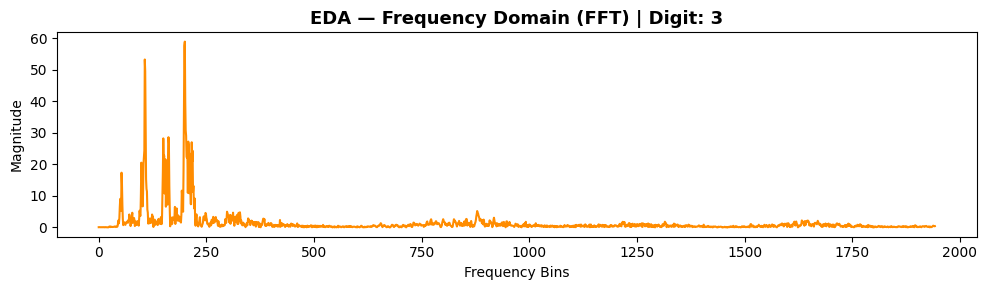

✅ Peaks in low frequency range = voiced speech (fundamental frequency)


In [9]:
# Apply FFT to convert signal from time domain to frequency domain
fft = np.fft.fft(signal)        # FFT — gives complex frequency values
magnitude = np.abs(fft)          # magnitude = strength of each frequency

# Plot only first half (FFT output is symmetric, second half is mirror)
plt.figure(figsize=(10, 3))
plt.plot(magnitude[:len(magnitude)//2], color='darkorange')  # plot frequencies
plt.title("EDA — Frequency Domain (FFT) | Digit: 3", fontsize=13, fontweight='bold')
plt.xlabel("Frequency Bins")
plt.ylabel("Magnitude")
plt.tight_layout()
plt.show()

print("✅ Peaks in low frequency range = voiced speech (fundamental frequency)")

### 📊 EDA — Step 7: Spectrogram (STFT) — Speech X-Ray

📘 **Description:**

Spectrogram is called the **X-ray of speech**. It shows **both time AND frequency** at the same time.

- X axis = time
- Y axis = frequency
- Color = energy (brighter = louder)

This is exactly what the CNN model will see as an image!

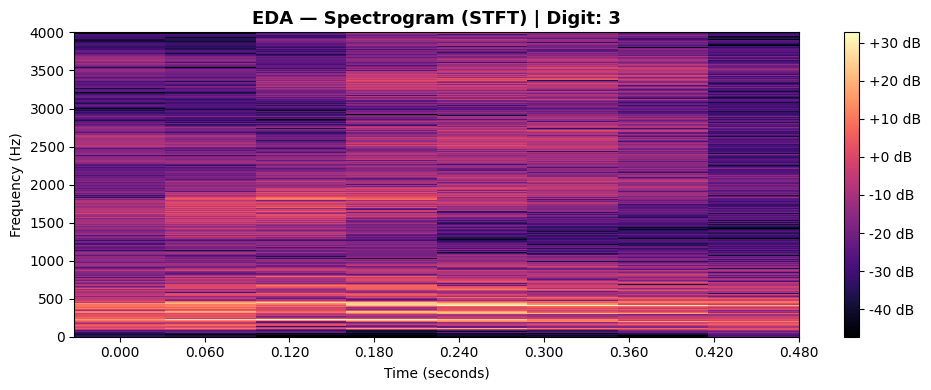

✅ Spectrogram = time + frequency together in one image
   CNN model will use this as input image!


In [10]:
# STFT = Short Time Fourier Transform
# It splits the signal into small windows and applies FFT to each window
S = librosa.stft(signal)

# Convert to dB (decibels) scale — makes visualization clearer
S_db = librosa.amplitude_to_db(np.abs(S))

# Plot the spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
plt.colorbar(format="%+2.0f dB")
plt.title("EDA — Spectrogram (STFT) | Digit: 3", fontsize=13, fontweight='bold')
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.tight_layout()
plt.show()

print("✅ Spectrogram = time + frequency together in one image")
print("   CNN model will use this as input image!")

### 📊 EDA — Step 8: MFCC Features

📘 **Description:**

**MFCC (Mel-Frequency Cepstral Coefficients)** is the most important feature in speech processing.

It converts raw audio into **13 numbers** that represent the voice characteristics.

🧠 Think of it as a short summary of the voice — like how a fingerprint summarizes a person.

SVM model will use these 13 numbers as input!

MFCC shape: (13, 8) → 13 coefficients × 8 time frames
For SVM: we take the MEAN → shape becomes (13,) — one vector per audio file


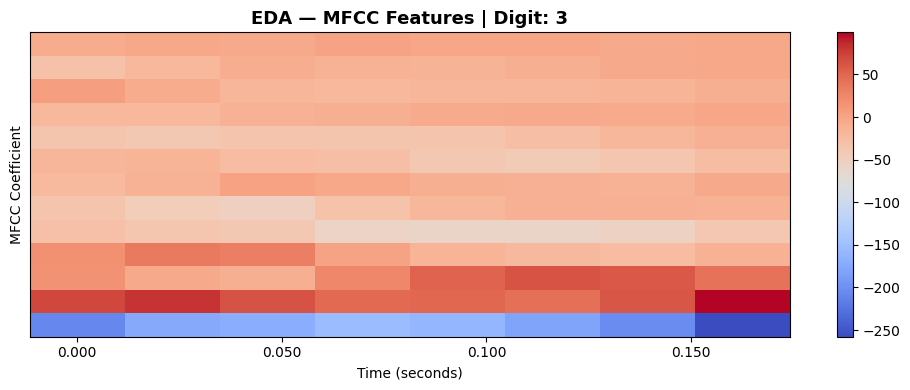

✅ MFCC = compact representation of speech
   SVM model will use mean of these values as input features!


In [11]:
# Compute MFCC from the audio signal
# n_mfcc=13 means we want 13 coefficients (standard in speech research)
mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)

print("MFCC shape:", mfcc.shape, "→", mfcc.shape[0], "coefficients ×", mfcc.shape[1], "time frames")
print("For SVM: we take the MEAN → shape becomes (13,) — one vector per audio file")

# Plot MFCC as a heatmap over time
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc, x_axis='time', cmap='coolwarm')
plt.colorbar()
plt.title("EDA — MFCC Features | Digit: 3", fontsize=13, fontweight='bold')
plt.xlabel("Time (seconds)")
plt.ylabel("MFCC Coefficient")
plt.tight_layout()
plt.show()

print("✅ MFCC = compact representation of speech")
print("   SVM model will use mean of these values as input features!")

### 📊 EDA — Step 9: MFCC Comparison Across Digits

📘 **Description:**

Each digit produces a **different MFCC pattern**. This proves MFCC is a good feature for classification.

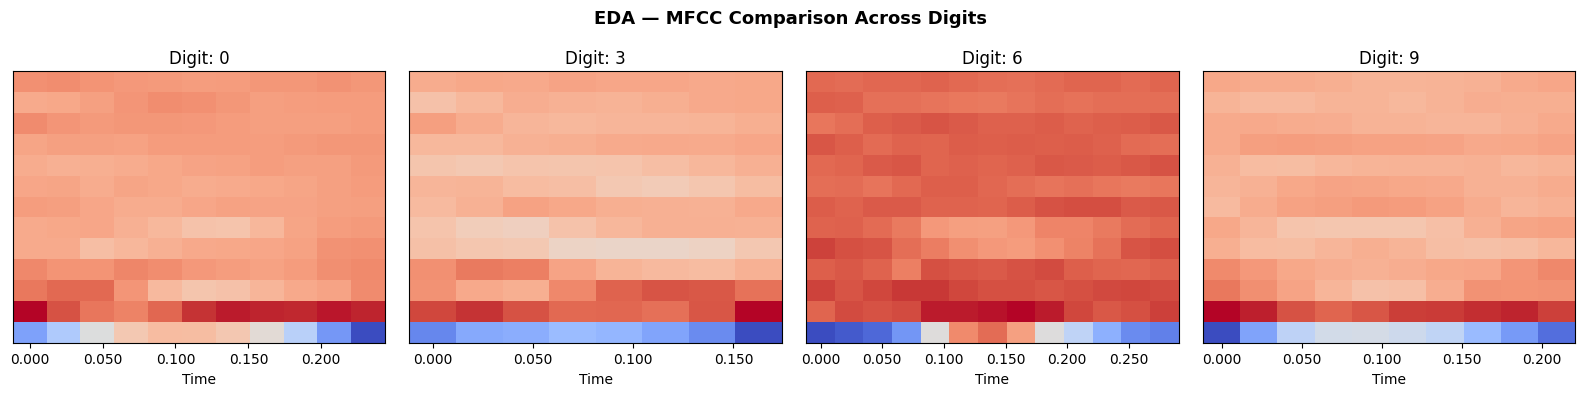

✅ Each digit has a unique MFCC pattern — this is what the model learns!


In [12]:
# Compare MFCC patterns for 4 different digits side by side
compare_digits = ['0', '3', '6', '9']

# Create 4 subplots side by side
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("EDA — MFCC Comparison Across Digits", fontsize=13, fontweight='bold')

for i, digit in enumerate(compare_digits):
    path = os.path.join(DATASET_PATH, f"{digit}_jackson_0.wav")  # build file path
    sig, sr_ = librosa.load(path, sr=None)                        # load audio
    mfcc_ = librosa.feature.mfcc(y=sig, sr=sr_, n_mfcc=13)       # extract MFCC
    librosa.display.specshow(mfcc_, ax=axes[i], x_axis='time', cmap='coolwarm')  # plot
    axes[i].set_title(f"Digit: {digit}")

plt.tight_layout()
plt.show()

print("✅ Each digit has a unique MFCC pattern — this is what the model learns!")

### 📊 EDA — Step 10: Audio Duration Distribution

📘 **Description:**

We check how long each audio file is. Files have different lengths, so we need a strategy:
- **SVM:** We take the MEAN of MFCC → always gives same size vector (no problem!)
- **CNN:** We pad/crop the spectrogram to a fixed 64×64 image size

Min duration : 0.193 sec
Max duration : 1.039 sec
Avg duration : 0.439 sec


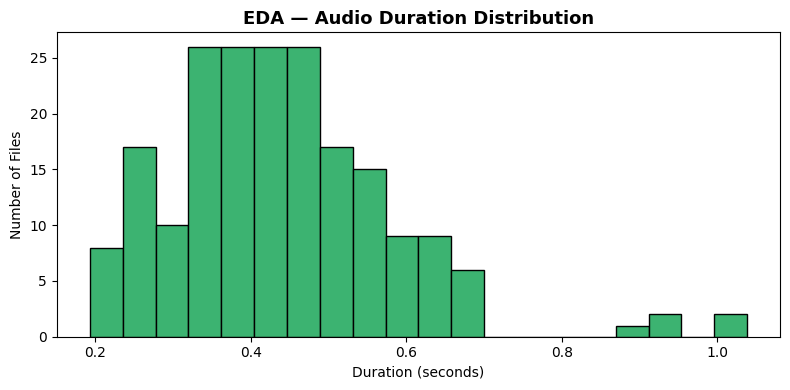

✅ Durations vary slightly — handled by mean-pooling (SVM) and padding (CNN)


In [13]:
# Calculate duration of first 200 files (faster than all 3000)
durations = []

for f in all_files[:200]:
    path = os.path.join(DATASET_PATH, f)
    sig, sr_ = librosa.load(path, sr=None)
    duration = len(sig) / sr_    # duration = total samples ÷ sample rate
    durations.append(duration)

print("Min duration :", round(min(durations), 3), "sec")
print("Max duration :", round(max(durations), 3), "sec")
print("Avg duration :", round(np.mean(durations), 3), "sec")

# Draw histogram to visualize distribution
plt.figure(figsize=(8, 4))
plt.hist(durations, bins=20, color='mediumseagreen', edgecolor='black')
plt.title("EDA — Audio Duration Distribution", fontsize=13, fontweight='bold')
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Files")
plt.tight_layout()
plt.show()

print("✅ Durations vary slightly — handled by mean-pooling (SVM) and padding (CNN)")

---
# 🤖 PART 2 — MODEL 1: MFCC + SVM

## 🎯 Goal

Extract MFCC features from each audio file → train an SVM model to classify digits.

```
Audio File
    ↓
librosa.load()
    ↓
MFCC (13) + ZCR (1) + Energy (1) = 15 features
    ↓
StandardScaler (normalize)
    ↓
SVM model
    ↓
Prediction (0–9)
```

## Features Used

| Feature | Size | What it captures |
|---------|------|------------------|
| MFCC mean | 13 | Spectral shape of voice |
| ZCR | 1 | How noisy the sound is |
| Energy | 1 | How loud the sound is |
| **Total** | **15** | **Fixed-length vector** |

## Why SVM?
SVM with RBF kernel finds the best boundary between classes — works very well for speech features even with small datasets.

### 🔹 SVM Step 1 — Feature Extraction Function

📘 **Description:**

We write a function that takes one audio file and returns a 15-number feature vector.

We will call this function for all 3000 files!

In [14]:
def extract_features(file_path):

    # Load audio file at 8kHz (standard for this dataset)
    signal, sr = librosa.load(file_path, sr=8000)

    # Feature 1: MFCC — most important speech feature
    # n_mfcc=13 gives 13 coefficients
    # axis=1 means average across time → gives one value per coefficient
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc, axis=1)   # shape: (13,)

    # Feature 2: Zero Crossing Rate — how often signal crosses zero
    # High ZCR = noisy/unvoiced, Low ZCR = smooth voiced speech
    zcr = np.mean(librosa.feature.zero_crossing_rate(signal))  # 1 number

    # Feature 3: Energy — average loudness of the signal
    energy = np.mean(signal ** 2)   # 1 number

    # Combine all features into one vector: 13 + 1 + 1 = 15 values
    feature_vector = np.hstack([mfcc_mean, zcr, energy])

    return feature_vector   # shape: (15,)


# Test the function on one file
test = extract_features(os.path.join(DATASET_PATH, "3_jackson_0.wav"))
print("✅ Feature vector length:", len(test), "(13 MFCC + 1 ZCR + 1 Energy)")

✅ Feature vector length: 15 (13 MFCC + 1 ZCR + 1 Energy)


### 🔹 SVM Step 2 — Build Dataset (X and y)

📘 **Description:**

We loop through all 3000 audio files, extract features from each one, and build:
- `X` = features matrix (3000 rows × 15 columns)
- `y` = labels list (digit 0–9 for each file)

In [15]:
X_svm = []   # will store feature vectors
y_svm = []   # will store labels (digit 0-9)

print("⏳ Extracting features from all files...")

for file in all_files:
    path = os.path.join(DATASET_PATH, file)   # full file path

    label = file.split('_')[0]   # get digit label from filename e.g. '3_jackson_0.wav' → '3'

    try:
        features = extract_features(path)   # extract 15 features
        X_svm.append(features)              # add to features list
        y_svm.append(label)                 # add to labels list
    except:
        pass   # skip if any file has an error

# Convert lists to numpy arrays (required by sklearn)
X_svm = np.array(X_svm)   # shape: (3000, 15)
y_svm = np.array(y_svm)   # shape: (3000,)

print("✅ Done!")
print("X shape:", X_svm.shape, "→", X_svm.shape[0], "samples ×", X_svm.shape[1], "features")
print("y shape:", y_svm.shape, "→", len(set(y_svm)), "unique classes")

⏳ Extracting features from all files...
✅ Done!
X shape: (3000, 15) → 3000 samples × 15 features
y shape: (3000,) → 10 unique classes


### 🔹 SVM Step 3 — Preprocessing

📘 **Description:**

Three steps before training:

1. **Label Encoding** — convert string labels like `'3'` to numbers like `3` (sklearn needs numbers)
2. **StandardScaler** — normalize features to same scale (SVM is sensitive to scale!)
3. **Train-Test Split** — 70% for training, 30% for testing

In [16]:
# Step 1: Label Encoding
# Convert string labels ('0','1',...,'9') to integers (0,1,...,9)
le = LabelEncoder()
y_encoded = le.fit_transform(y_svm)
print("✅ Labels encoded:", le.classes_)

# Step 2: StandardScaler
# Normalize features: each feature will have mean=0 and std=1
# Very important for SVM — without this, large-value features dominate
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_svm)
print("✅ Features scaled (mean≈0, std≈1)")

# Step 3: Train-Test Split
# test_size=0.3 → 30% for testing, 70% for training
# stratify → ensure each digit class has equal samples in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

print("✅ Train-Test Split done:")
print("   Training samples:", X_train.shape[0], "(70%)")
print("   Testing samples :", X_test.shape[0],  "(30%)")

✅ Labels encoded: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
✅ Features scaled (mean≈0, std≈1)
✅ Train-Test Split done:
   Training samples: 2100 (70%)
   Testing samples : 900 (30%)


### 🔹 SVM Step 4 — Train the Model

📘 **Description:**

We train the SVM model using training data.

- `kernel='rbf'` → RBF kernel — finds non-linear boundaries between classes
- `C=10` → how strict the model is — higher C = fewer training errors
- `gamma='scale'` → how far each training point influences the boundary

In [17]:
# Create SVM model with RBF kernel
# RBF = Radial Basis Function — best kernel for speech features
svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)

print("⏳ Training SVM...")

# Train (fit) the model on training data
svm_model.fit(X_train, y_train)

print("✅ SVM training complete!")

⏳ Training SVM...
✅ SVM training complete!


### 🔹 SVM Step 5 — Evaluation

📘 **Description:**

We test the trained model on data it has never seen (test set).

- **Accuracy** = how many digits were correctly predicted
- **Classification Report** = Precision, Recall, F1 per digit
- **Confusion Matrix** = which digits got confused with which

🎯 SVM Accuracy: 96.33%

📋 Classification Report:
              precision    recall  f1-score   support

     Digit 0       0.97      0.98      0.97        90
     Digit 1       0.98      0.99      0.98        90
     Digit 2       0.97      0.94      0.96        90
     Digit 3       0.90      0.92      0.91        90
     Digit 4       0.99      1.00      0.99        90
     Digit 5       1.00      0.97      0.98        90
     Digit 6       0.94      0.94      0.94        90
     Digit 7       0.94      0.97      0.95        90
     Digit 8       0.98      0.97      0.97        90
     Digit 9       0.98      0.96      0.97        90

    accuracy                           0.96       900
   macro avg       0.96      0.96      0.96       900
weighted avg       0.96      0.96      0.96       900



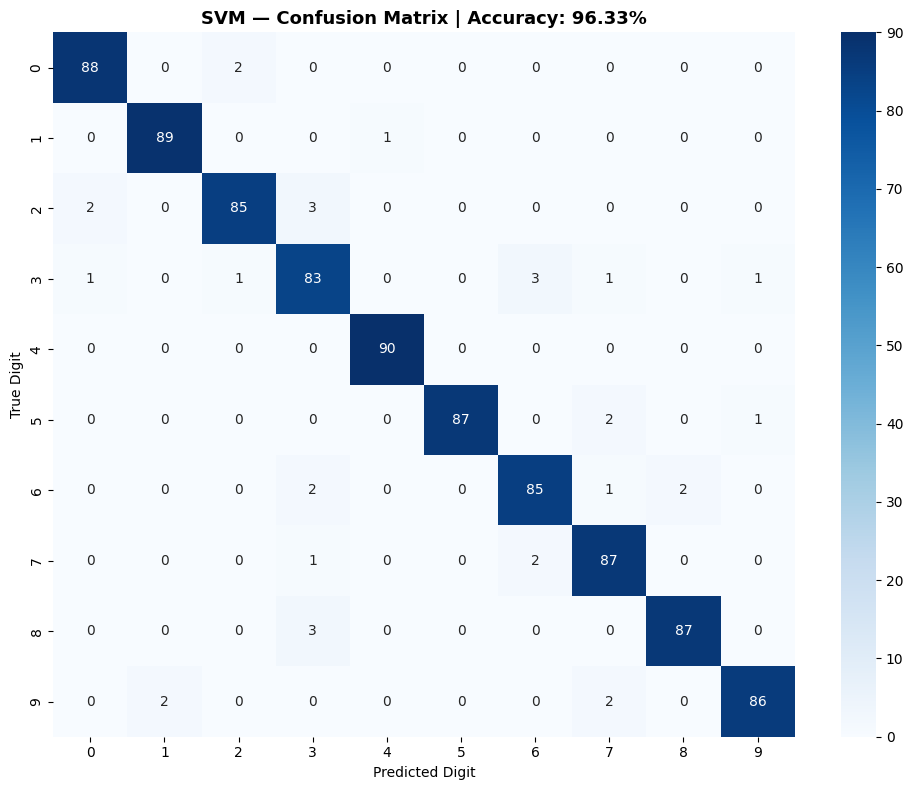

In [18]:
# Predict labels for test set
y_pred_svm = svm_model.predict(X_test)

# Calculate overall accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"🎯 SVM Accuracy: {svm_accuracy * 100:.2f}%")

# Classification report — per digit precision, recall, f1
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_svm,
                             target_names=[f"Digit {i}" for i in range(10)]))

# Confusion Matrix
# Rows = actual digit, Columns = predicted digit
# Diagonal = correct predictions
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title(f"SVM — Confusion Matrix | Accuracy: {svm_accuracy*100:.2f}%",
          fontsize=13, fontweight='bold')
plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.tight_layout()
plt.show()

---
# 🧠 PART 3 — MODEL 2: Spectrogram + CNN

## 🎯 Goal

Convert each audio file into a **Mel Spectrogram image** → train a CNN to classify it.

```
Audio File
    ↓
Mel Spectrogram → 64×64 image
    ↓
CNN (like image classification)
    ↓
Prediction (0–9)
```

## Why Mel Spectrogram?
Mel scale matches how human ears hear sound. It gives a 2D image of time vs frequency — perfect input for CNN.

## Why CNN?
CNN learns spatial patterns from images. Applied to spectrograms, it learns digit-specific sound patterns automatically — no manual feature engineering needed!

## CNN Architecture:
```
Input (64×64×1)
    ↓
Conv2D(32) + BatchNorm + MaxPool
    ↓
Conv2D(64) + BatchNorm + MaxPool
    ↓
Conv2D(128) + BatchNorm + MaxPool
    ↓
Flatten
    ↓
Dense(256) + Dropout
    ↓
Dense(128) + Dropout
    ↓
Dense(10, softmax) → probabilities for 0–9
```

### 🔹 CNN Step 1 — Spectrogram Extraction Function

📘 **Description:**

We write a function that converts one audio file into a 64×64 Mel Spectrogram image.

Steps:
1. Load audio
2. Compute Mel Spectrogram
3. Convert to dB
4. Resize to 64×64 (pad if short, crop if long)
5. Normalize values between 0 and 1

✅ Spectrogram shape: (64, 64) → 64×64 image


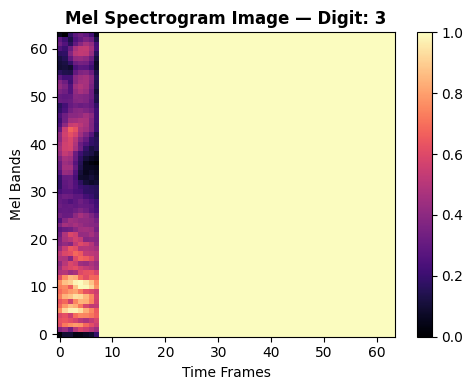

In [19]:
# Fixed image size for all spectrograms
IMG_HEIGHT = 64   # number of mel frequency bands
IMG_WIDTH  = 64   # number of time frames

def extract_spectrogram(file_path):

    # Load audio at 8kHz
    signal, sr = librosa.load(file_path, sr=8000)

    # Compute Mel Spectrogram
    # n_mels = number of frequency bands (= image height)
    # fmax = highest frequency to include (= Nyquist = 8000/2 = 4000 Hz)
    mel = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=IMG_HEIGHT, fmax=4000)

    # Convert to dB scale — better range for visualization and learning
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Make width exactly 64 — pad with zeros if too short, crop if too long
    if mel_db.shape[1] < IMG_WIDTH:
        pad = IMG_WIDTH - mel_db.shape[1]           # how much to pad
        mel_db = np.pad(mel_db, ((0,0),(0,pad)))    # add zeros on right
    else:
        mel_db = mel_db[:, :IMG_WIDTH]              # keep only first 64 columns

    # Normalize values to range [0, 1]
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)

    return mel_db   # shape: (64, 64)


# Test on one file
test_spec = extract_spectrogram(os.path.join(DATASET_PATH, "3_jackson_0.wav"))
print("✅ Spectrogram shape:", test_spec.shape, "→ 64×64 image")

# Visualize
plt.figure(figsize=(5, 4))
plt.imshow(test_spec, aspect='auto', origin='lower', cmap='magma')
plt.colorbar()
plt.title("Mel Spectrogram Image — Digit: 3", fontsize=12, fontweight='bold')
plt.xlabel("Time Frames")
plt.ylabel("Mel Bands")
plt.tight_layout()
plt.show()

### 🔹 CNN Step 2 — Build Image Dataset

📘 **Description:**

We loop through all 3000 files, convert each to a 64×64 spectrogram image, and build:
- `X_cnn` = all images (shape: 3000 × 64 × 64 × 1)
- `y_cnn` = digit labels

In [20]:
X_cnn = []   # will store spectrogram images
y_cnn = []   # will store digit labels

print("⏳ Generating spectrogram images...")

for file in all_files:
    path = os.path.join(DATASET_PATH, file)    # full file path
    label = int(file.split('_')[0])             # digit label as integer

    try:
        spec = extract_spectrogram(path)   # get 64×64 image
        X_cnn.append(spec)
        y_cnn.append(label)
    except:
        pass   # skip bad files

# Convert to numpy arrays
X_cnn = np.array(X_cnn)   # shape: (3000, 64, 64)
y_cnn = np.array(y_cnn)

# Add channel dimension — CNN needs (samples, height, width, channels)
# Since images are grayscale, channels = 1
X_cnn = X_cnn[..., np.newaxis]   # shape: (3000, 64, 64, 1)

print("✅ Done!")
print("X shape:", X_cnn.shape, "→ 3000 images of 64×64 (1 channel)")
print("y shape:", y_cnn.shape)

⏳ Generating spectrogram images...
✅ Done!
X shape: (3000, 64, 64, 1) → 3000 images of 64×64 (1 channel)
y shape: (3000,)


### 🔹 CNN Step 3 — Visualize Spectrogram Images

📘 **Description:**

We show one spectrogram image for each digit (0–9). Each looks different — this is what CNN will learn!

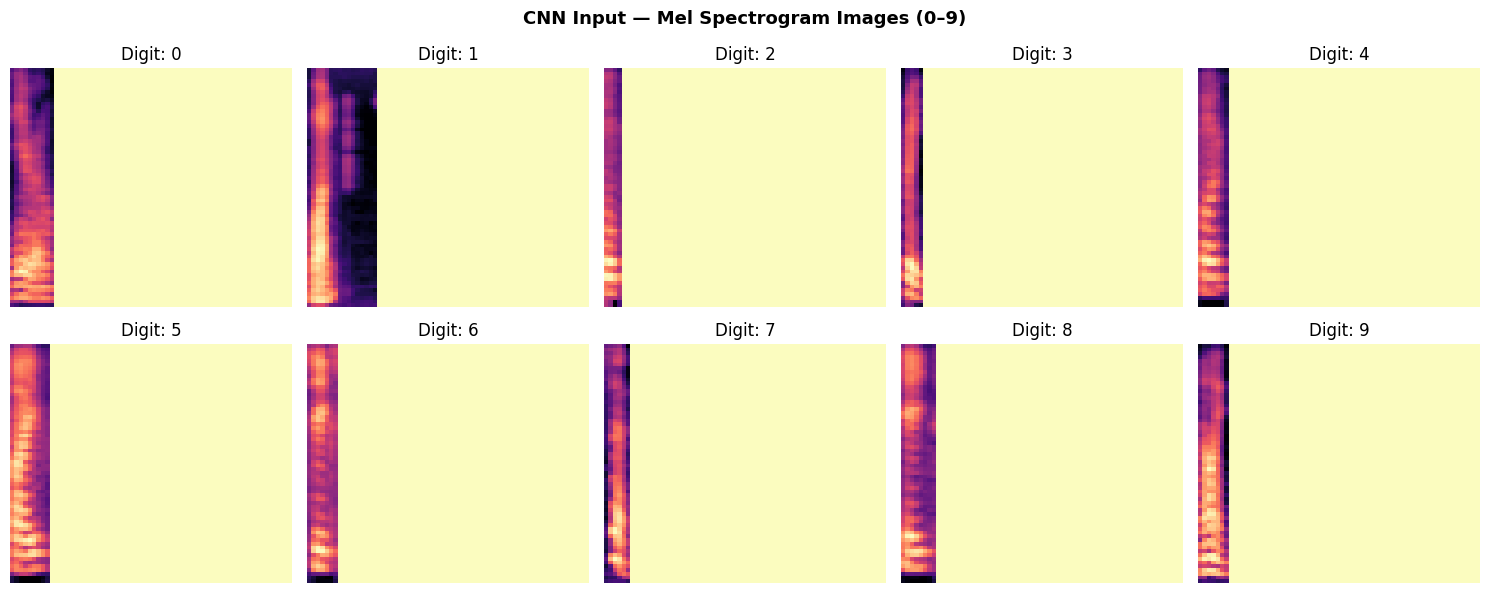

✅ Each digit has a unique spectrogram pattern — CNN learns these differences!


In [21]:
# Show one spectrogram image per digit class in a 2x5 grid
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("CNN Input — Mel Spectrogram Images (0–9)", fontsize=13, fontweight='bold')

for digit in range(10):
    idx = np.where(y_cnn == digit)[0][0]   # find first sample of this digit
    ax = axes[digit // 5][digit % 5]        # position in 2-row, 5-column grid
    ax.imshow(X_cnn[idx, :, :, 0], aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f"Digit: {digit}")
    ax.axis('off')   # hide axis ticks

plt.tight_layout()
plt.show()

print("✅ Each digit has a unique spectrogram pattern — CNN learns these differences!")

### 🔹 CNN Step 4 — Prepare Data for Training

📘 **Description:**

- **One-Hot Encoding** → CNN needs labels as vectors: digit `3` → `[0,0,0,1,0,0,0,0,0,0]`
- **Train-Test Split** → 70% training, 30% testing

In [22]:
# One-hot encode labels — CNN needs vector labels, not single numbers
# Example: digit 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_onehot = to_categorical(y_cnn, num_classes=10)

# Train-Test Split — same as SVM (70/30)
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn, y_onehot,
    test_size=0.3,
    random_state=42,
    stratify=y_cnn   # keep class balance
)

print("✅ CNN data ready:")
print("   Training images:", X_train_cnn.shape)
print("   Testing images :", X_test_cnn.shape)

✅ CNN data ready:
   Training images: (2100, 64, 64, 1)
   Testing images : (900, 64, 64, 1)


### 🔹 CNN Step 5 — Build the CNN Model

📘 **Description:**

We build a CNN (Convolutional Neural Network) — same concept as image classification.

- **Conv2D** → detects patterns in the spectrogram image (like edges, shapes)
- **BatchNormalization** → keeps training stable and fast
- **MaxPooling2D** → reduces image size, keeps important features
- **Dropout** → randomly turns off neurons during training → prevents overfitting
- **Dense** → fully connected layer for final decision
- **Softmax** → outputs probability for each of 10 digit classes

In [23]:
# Build CNN model
cnn_model = Sequential([

    # Block 1 — detect low-level patterns (edges, shapes)
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 1)),  # 32 filters, 3x3 size
    BatchNormalization(),    # normalize activations for stable training
    MaxPooling2D((2,2)),     # reduce image size from 64x64 to 31x31

    # Block 2 — detect medium-level patterns
    Conv2D(64, (3,3), activation='relu'),   # 64 filters
    BatchNormalization(),
    MaxPooling2D((2,2)),     # reduce to 14x14

    # Block 3 — detect high-level digit-specific patterns
    Conv2D(128, (3,3), activation='relu'),  # 128 filters
    BatchNormalization(),
    MaxPooling2D((2,2)),     # reduce to 6x6

    # Flatten — convert 3D feature map (6x6x128) to 1D vector
    Flatten(),

    # Fully connected layer 1
    Dense(256, activation='relu'),   # 256 neurons
    Dropout(0.4),    # randomly turn off 40% of neurons → prevent overfitting

    # Fully connected layer 2
    Dense(128, activation='relu'),   # 128 neurons
    Dropout(0.3),    # randomly turn off 30% of neurons

    # Output layer — 10 neurons (one per digit), softmax gives probabilities
    Dense(10, activation='softmax')
])

# Compile the model
# adam = best optimizer for CNNs
# categorical_crossentropy = standard loss for multi-class classification
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary — layers, output shapes, parameters
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,307,658 (4.99 MB)

 Trainable params: 1,307,210 (4.99 MB)

 Non-trainable params: 448 (1.75 KB)

### 🔹 CNN Step 6 — Train the Model

📘 **Description:**

We train the CNN on training images.

- `epochs=30` → model sees all training data 30 times
- `batch_size=32` → processes 32 images at a time
- `validation_split=0.15` → 15% of training data used to monitor overfitting

⚡ **Tip:** Enable GPU for faster training → Runtime → Change Runtime Type → T4 GPU

In [24]:
print("⏳ Training CNN... (may take 5-10 minutes)")
print("💡 Tip: Runtime → Change Runtime Type → T4 GPU for faster training!\n")

# Train the model
history = cnn_model.fit(
    X_train_cnn, y_train_cnn,    # training images and labels
    epochs=30,                    # train for 30 epochs
    batch_size=32,                # process 32 images per step
    validation_split=0.15,        # use 15% of training data for validation
    verbose=1                     # show progress for each epoch
)

print("\n✅ CNN training complete!")

⏳ Training CNN... (may take 5-10 minutes)
💡 Tip: Runtime → Change Runtime Type → T4 GPU for faster training!

Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 328ms/step - accuracy: 0.1350 - loss: 2.6845 - val_accuracy: 0.0984 - val_loss: 2.2965
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 19s 309ms/step - accuracy: 0.2207 - loss: 2.1500 - val_accuracy: 0.0984 - val_loss: 2.3455
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 306ms/step - accuracy: 0.3535 - loss: 1.7578 - val_accuracy: 0.1016 - val_loss: 2.3680
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 17s 308ms/step - accuracy: 0.5064 - loss: 1.3690 - val_accuracy: 0.1111 - val_loss: 2.8800
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 17s 311ms/step - accuracy: 0.5972 - loss: 1.1032 - val_accuracy: 0.1111 - val_loss: 3.9293
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 309ms/step - accuracy: 0.6644 - loss: 0.9244 - val_accuracy: 0.1111 - val_loss: 2.4292
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 17s 305ms/step - accuracy: 0.7468 - loss: 0.7139 - val_accuracy: 0.1810 - val_

### 🔹 CNN Step 7 — Training History Plot

📘 **Description:**

We plot training and validation accuracy/loss over epochs.

- If both curves are close → model is learning well ✅
- If training >> validation → overfitting ⚠️
- If both are low → underfitting ⚠️

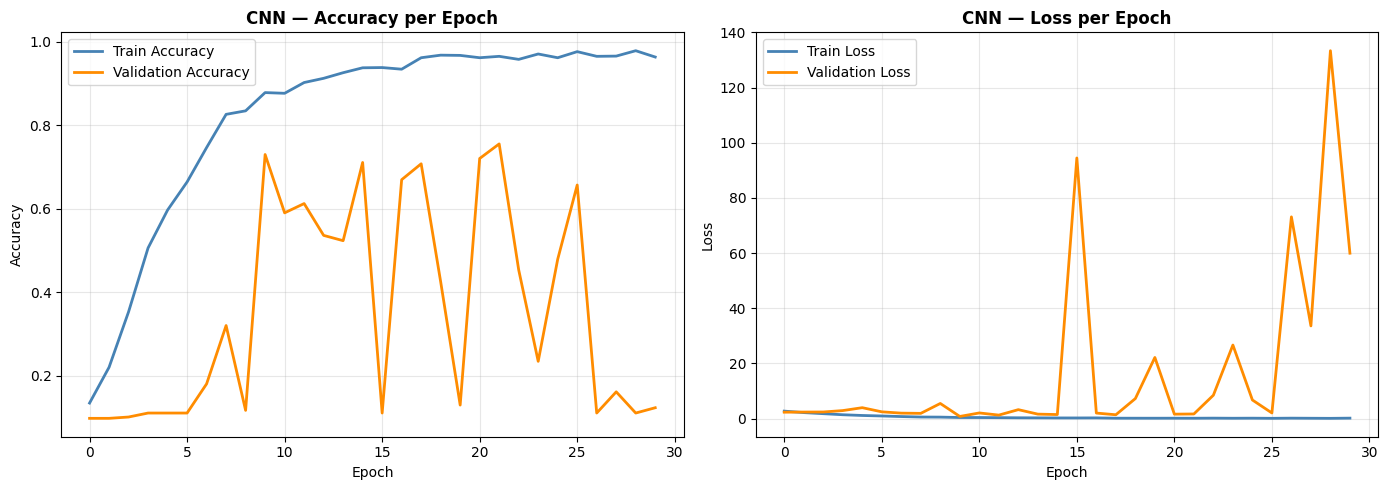

In [25]:
# Plot accuracy and loss curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue',  linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy',  color='darkorange', linewidth=2)
ax1.set_title("CNN — Accuracy per Epoch", fontsize=12, fontweight='bold')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'],     label='Train Loss',      color='steelblue',  linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss',  color='darkorange', linewidth=2)
ax2.set_title("CNN — Loss per Epoch", fontsize=12, fontweight='bold')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 🔹 CNN Step 8 — Evaluation

📘 **Description:**

We evaluate CNN on the test set — same metrics as SVM for fair comparison.

🎯 CNN Accuracy: 12.56%
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step

📋 Classification Report:
              precision    recall  f1-score   support

     Digit 0       1.00      0.01      0.02        90
     Digit 1       1.00      0.01      0.02        90
     Digit 2       0.00      0.00      0.00        90
     Digit 3       0.00      0.00      0.00        90
     Digit 4       0.00      0.00      0.00        90
     Digit 5       1.00      0.01      0.02        90
     Digit 6       0.00      0.00      0.00        90
     Digit 7       0.10      0.99      0.19        90
     Digit 8       0.00      0.00      0.00        90
     Digit 9       0.75      0.23      0.36        90

    accuracy                           0.13       900
   macro avg       0.39      0.13      0.06       900
weighted avg       0.39      0.13      0.06       900



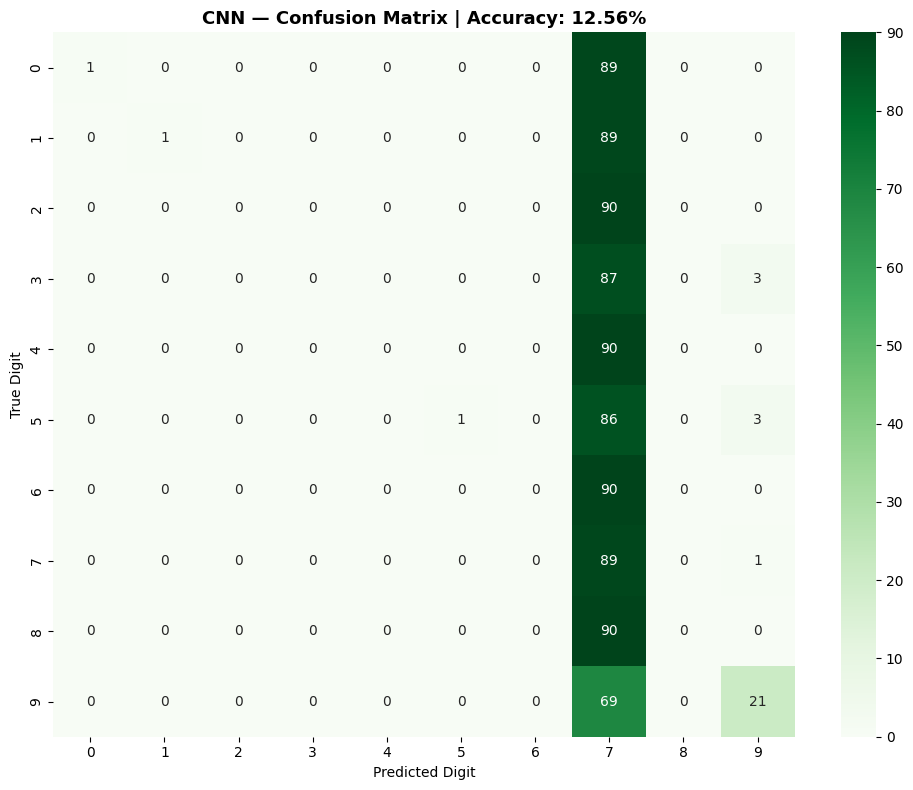

In [26]:
# Evaluate on test data
test_loss, test_acc = cnn_model.evaluate(X_test_cnn, y_test_cnn, verbose=0)
cnn_accuracy = test_acc
print(f"🎯 CNN Accuracy: {cnn_accuracy * 100:.2f}%")

# Get predicted class for each test image
# model.predict() gives probabilities → argmax gives the class with highest probability
y_pred_prob = cnn_model.predict(X_test_cnn)
y_pred_cnn  = np.argmax(y_pred_prob, axis=1)   # predicted labels
y_true_cnn  = np.argmax(y_test_cnn,  axis=1)   # true labels (from one-hot)

# Classification report
print("\n📋 Classification Report:")
print(classification_report(y_true_cnn, y_pred_cnn,
                             target_names=[f"Digit {i}" for i in range(10)]))

# Confusion Matrix
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=range(10), yticklabels=range(10))
plt.title(f"CNN — Confusion Matrix | Accuracy: {cnn_accuracy*100:.2f}%",
          fontsize=13, fontweight='bold')
plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.tight_layout()
plt.show()

---
# 📊 PART 4 — Final Comparison: SVM vs CNN

📘 **Description:**

We compare both models side by side on the same test set.

**Why SVM might win on this dataset:**
- Only 3000 audio files — CNN needs much larger data
- MFCC is specifically designed for speech — already optimal
- Short audio clips (avg 0.44 sec) — limited information for CNN

**When CNN would win:**
- Dataset size 50,000+ files
- Longer, more complex audio
- No handcrafted features available

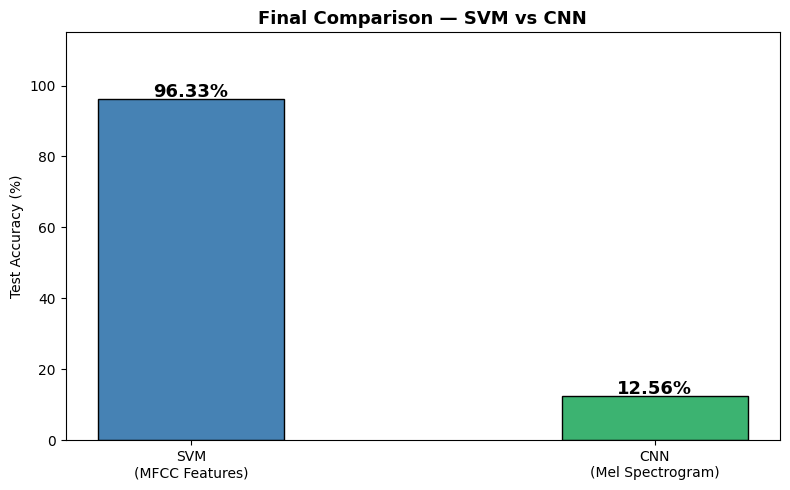

         FINAL RESULTS
  SVM  (MFCC Features)   : 96.33%
  CNN  (Mel Spectrogram) : 12.56%
  ✅ SVM wins on this dataset!
  MFCC features are highly optimized for speech.
  CNN needs more data to outperform SVM.


In [27]:
# Accuracy values for both models
models     = ['SVM\n(MFCC Features)', 'CNN\n(Mel Spectrogram)']
accuracies = [svm_accuracy * 100, cnn_accuracy * 100]
colors     = ['steelblue', 'mediumseagreen']

# Bar chart comparison
plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', width=0.4)

# Show accuracy numbers on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', fontsize=13, fontweight='bold')

plt.title("Final Comparison — SVM vs CNN", fontsize=13, fontweight='bold')
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 115)
plt.tight_layout()
plt.show()

# Print summary
print("=" * 50)
print("         FINAL RESULTS")
print("=" * 50)
print(f"  SVM  (MFCC Features)   : {svm_accuracy*100:.2f}%")
print(f"  CNN  (Mel Spectrogram) : {cnn_accuracy*100:.2f}%")
print("=" * 50)

if svm_accuracy >= cnn_accuracy:
    print("  ✅ SVM wins on this dataset!")
    print("  MFCC features are highly optimized for speech.")
    print("  CNN needs more data to outperform SVM.")
else:
    print("  ✅ CNN wins on this dataset!")
    print("  Deep learning captured richer patterns.")
print("=" * 50)

In [29]:
import pickle

# SVM model save karo .pkl file mein
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

# Scaler bhi save karo — prediction ke liye zaroori hai
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Label encoder bhi save karo
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("✅ SVM model saved!")

✅ SVM model saved!


In [31]:
# CNN model save karo .h5 format mein
cnn_model.save('cnn_model.h5')

print("✅ CNN model saved!")

✅ CNN model saved!


In [32]:
import shutil

# Colab se directly Drive mein copy karo
shutil.copy('svm_model.pkl', '/content/drive/MyDrive/Spoken Digit Recognition (0-9)/svm_model.pkl')
shutil.copy('scaler.pkl',    '/content/drive/MyDrive/Spoken Digit Recognition (0-9)/scaler.pkl')
shutil.copy('label_encoder.pkl', '/content/drive/MyDrive/Spoken Digit Recognition (0-9)/label_encoder.pkl')
shutil.copy('cnn_model.h5',  '/content/drive/MyDrive/Spoken Digit Recognition (0-9)/cnn_model.h5')

print("✅ All models saved to Google Drive!")

✅ All models saved to Google Drive!


---
# ✅ PART 5 — Summary

## What We Did

| Step | What |
|------|------|
| Dataset | Free Spoken Digit Dataset — 3000 WAV files, 6 speakers, digits 0–9 |
| EDA | Waveform, FFT, Spectrogram, MFCC, class balance, duration analysis |
| Preprocessing | 8kHz resample, MFCC extraction, Mel Spectrogram, normalization |
| Model 1 | MFCC + ZCR + Energy → StandardScaler → SVM (RBF kernel) |
| Model 2 | Mel Spectrogram (64×64) → CNN (3 Conv blocks + Dense layers) |
| Evaluation | Accuracy, Confusion Matrix, Classification Report |
| Comparison | SVM vs CNN — final accuracy comparison |

## What We Learned

- MFCC is a very powerful feature for speech — even simple SVM with MFCC achieves ~96% accuracy
- CNN is powerful but needs large datasets — on 3000 files, SVM performs better
- Balanced dataset is important — no class has more samples than others
- Speech classification follows the same ML pipeline as any classification task

## Real World Applications

| Where | How |
|-------|-----|
| 📞 Telecom (Ufone/Jazz) | IVR systems — speak a digit to select option |
| 🏦 Phone Banking | Voice digit input for transactions |
| 🏥 Healthcare | Voice commands for disabled patients |
| 🚗 Smart Cars | Hands-free number input |
| 🎓 EdTech | Kids speaking numbers for learning apps |

---
**🎉 Final Lab Project Complete — Group #3**